## Name: Megha Rajeev
## Reg no: 23MIM10047
## Application No:IN26011193

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## DATA LOADING

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## DATA UNDERSTANDING

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [11]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [12]:
target_variable = "Churn"

print("Target Variable:", target_variable)

Target Variable: Churn


In [55]:
print(df["Churn"].value_counts())

print(df["Churn"].value_counts(normalize=True)*100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [56]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
[0 1]
--------------------------------------------------
SeniorCitizen
[0 1]
--------------------------------------------------
Partner
[1 0]
--------------------------------------------------
Dependents
[0 1]
--------------------------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService
[0 1]
--------------------------------------------------
MultipleLines
[1 0 2]
--------------------------------------------------
InternetService
[0 1 2]
--------------------------------------------------
OnlineSecurity
[0 2 1]
--------------------------------------------------
OnlineBackup
[2 0 1]
--------------------------------------------------
DeviceProtection
[0 2 1]
--------------------------------------------------
TechSuppor

In [57]:
(df == "").sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## DATA UNDERSTANDING SUMMARY
The Telco Customer Churn dataset contains 7043 customer records and 21 features, including demographic information, subscribed services, billing details, and customer churn status. Most features are categorical, while SeniorCitizen, tenure, and MonthlyCharges are numerical. The TotalCharges column is stored as an object due to blank entries and will be converted to a numerical datatype during preprocessing. The target variable, Churn, is a binary categorical feature indicating whether a customer has left the telecommunications company. The dataset contains no duplicate records and no missing (NaN) values, although blank strings in TotalCharges require preprocessing.

## EXPLORATORY DATA ANALYSIS (EDA)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

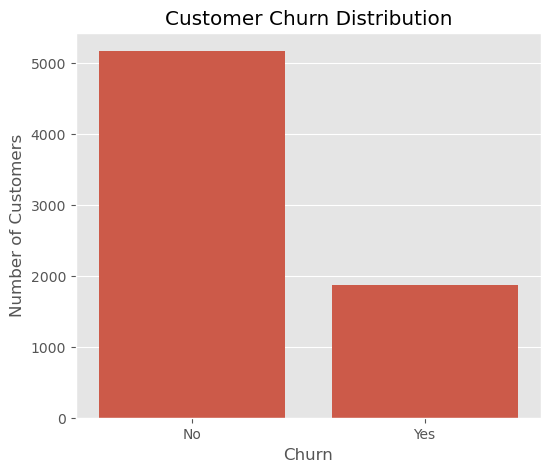

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

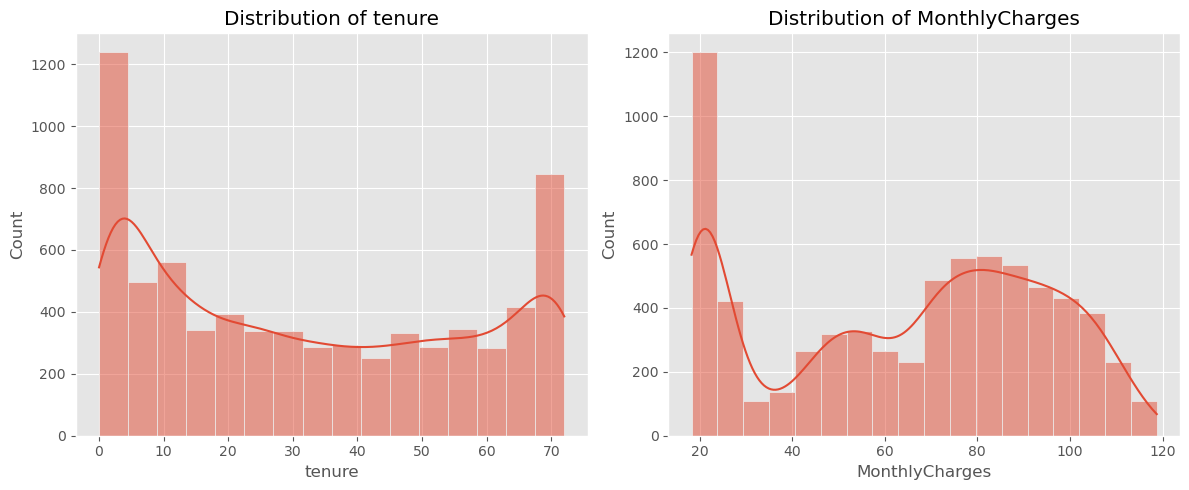

In [15]:
numerical_features = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

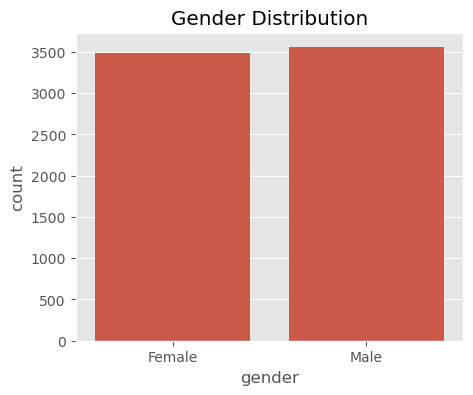

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

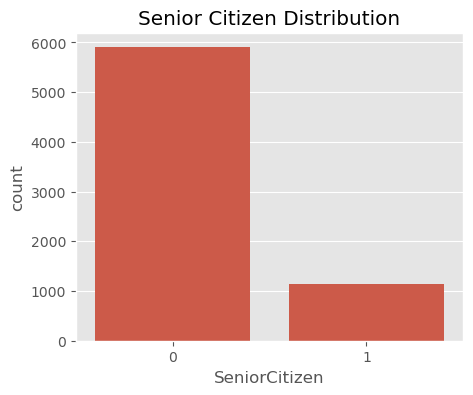

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x='SeniorCitizen', data=df)

plt.title("Senior Citizen Distribution")

plt.show()

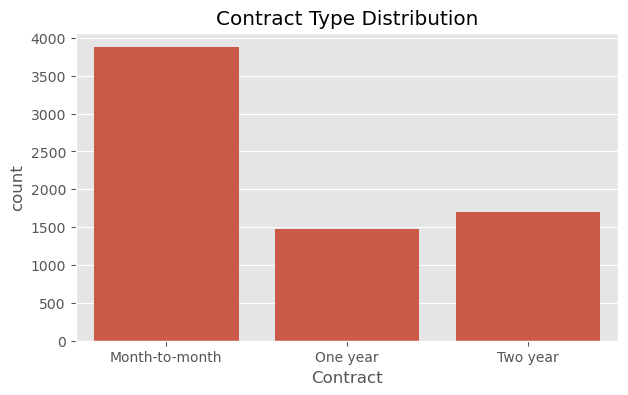

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', data=df)

plt.title("Contract Type Distribution")

plt.show()

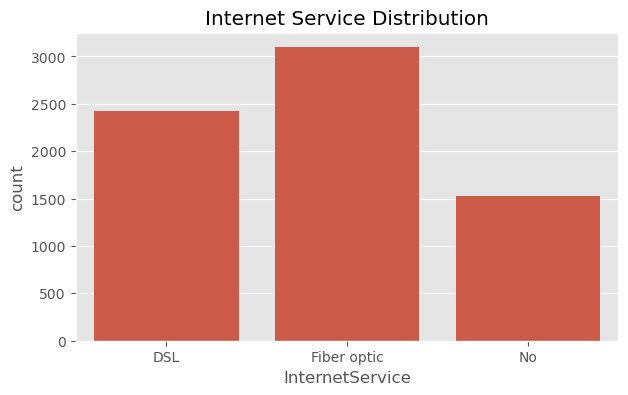

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', data=df)

plt.title("Internet Service Distribution")

plt.show()

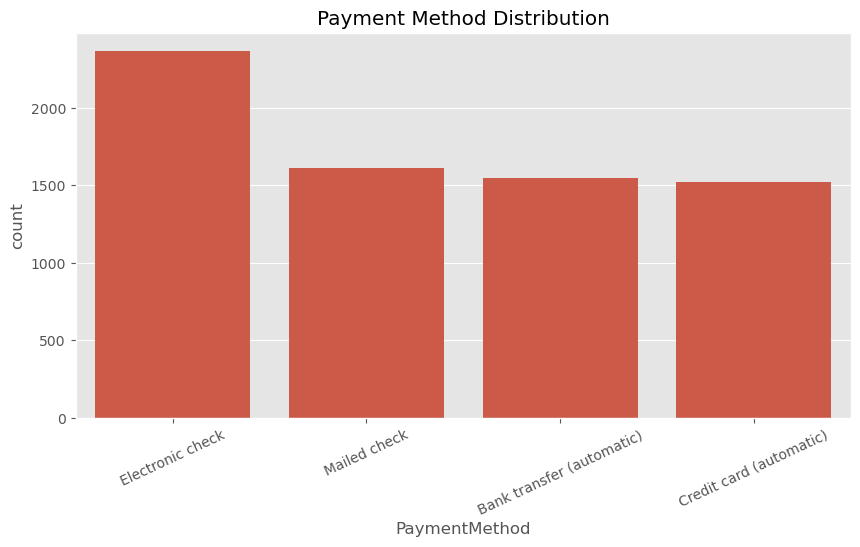

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', data=df)

plt.xticks(rotation=25)

plt.title("Payment Method Distribution")

plt.show()

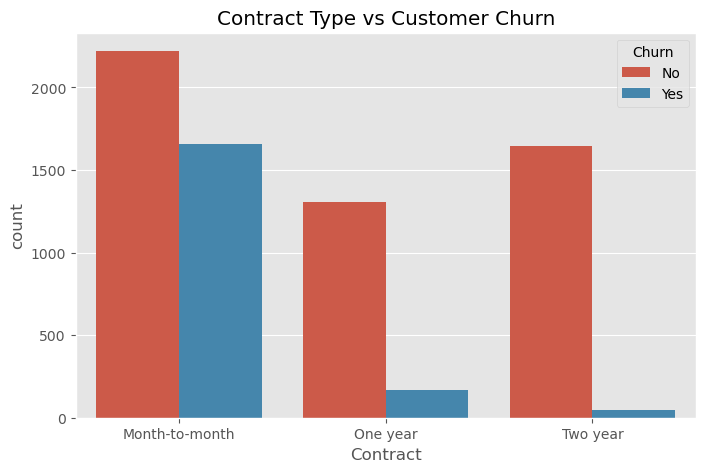

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")

plt.show()

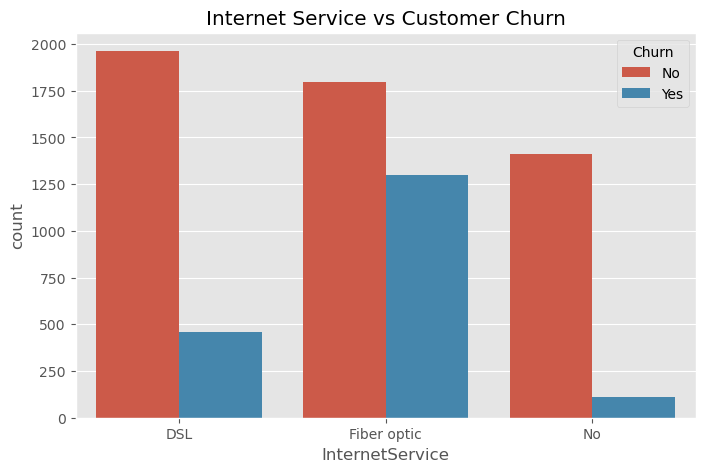

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Customer Churn")

plt.show()

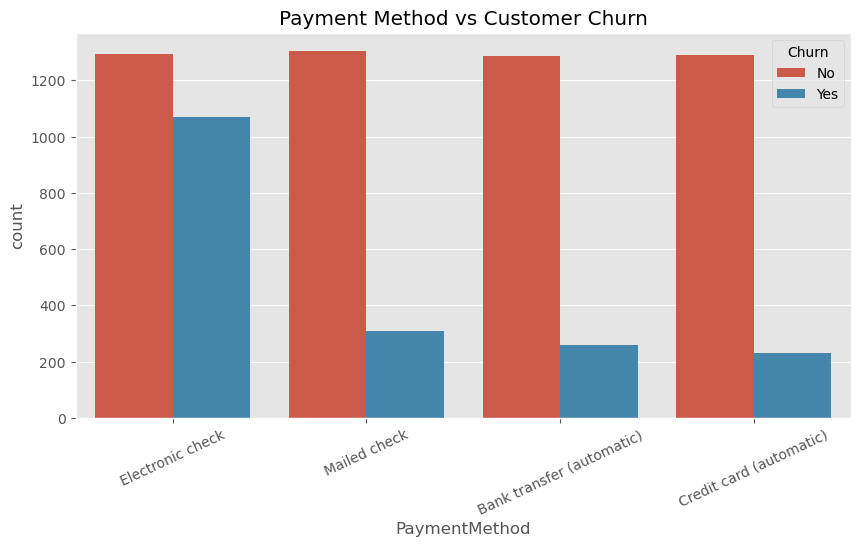

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=25)

plt.title("Payment Method vs Customer Churn")

plt.show()

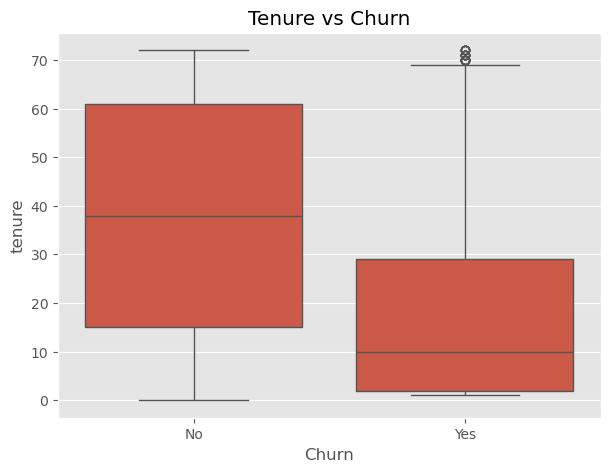

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

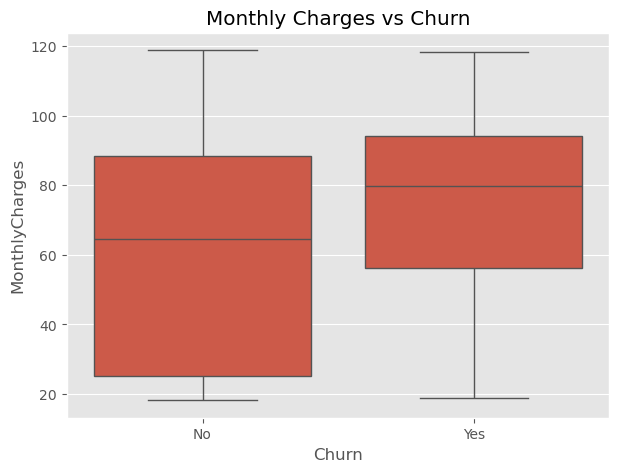

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

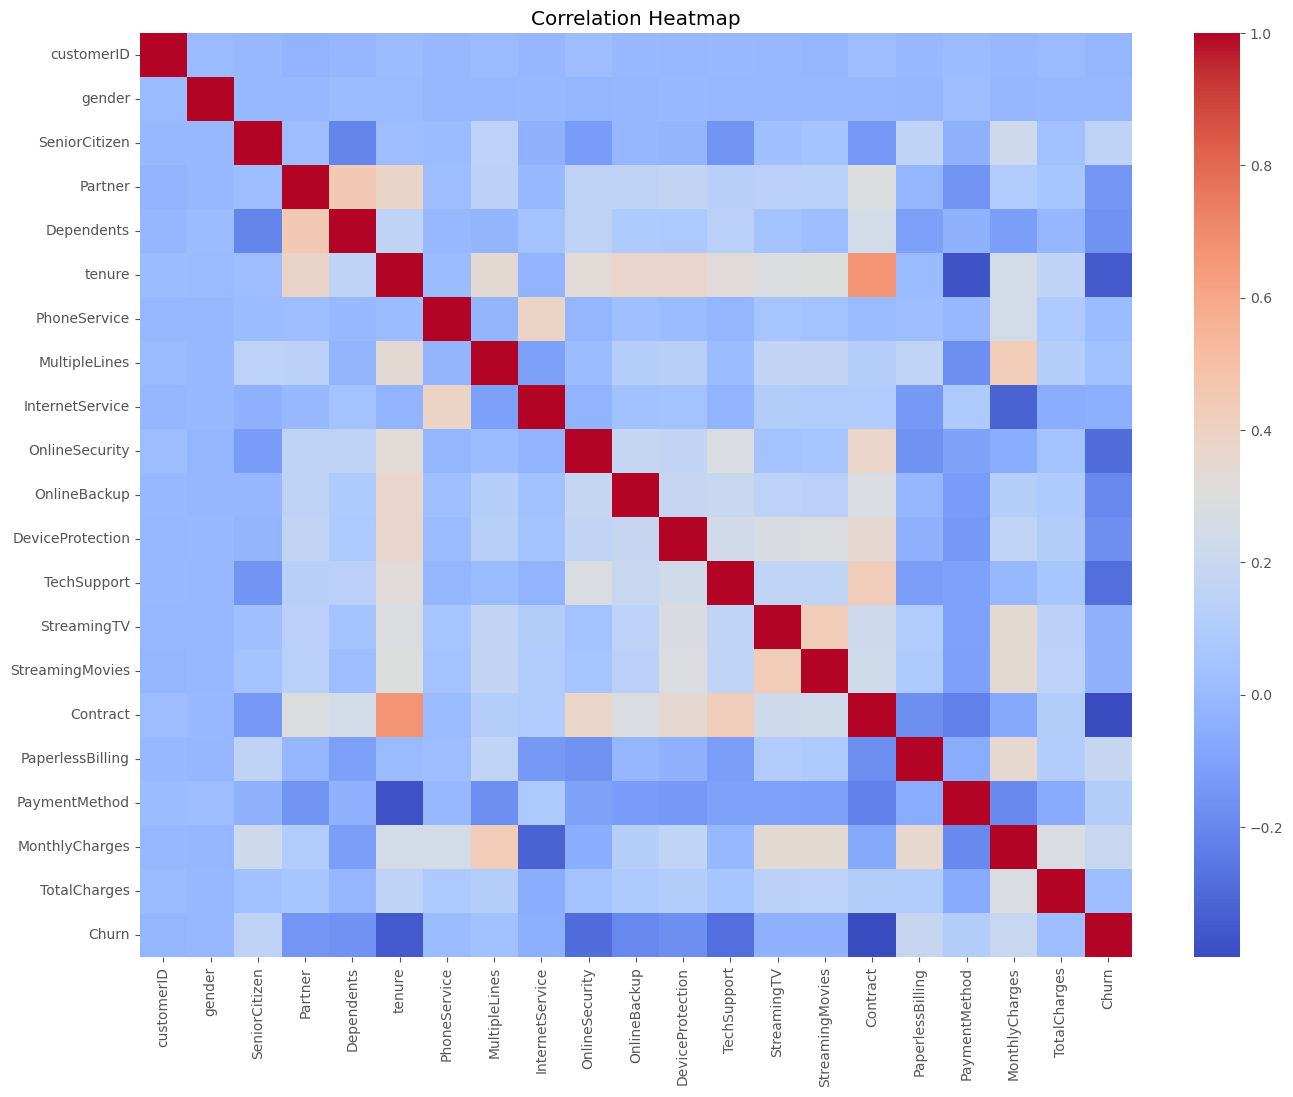

In [26]:
df_encoded = df.copy()

for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = LabelEncoder().fit_transform(df_encoded[column])

plt.figure(figsize=(16,12))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

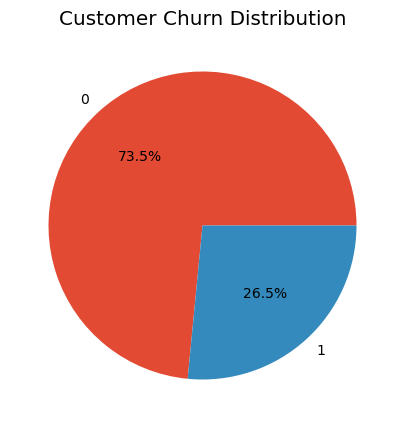

In [58]:
df["Churn"].value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(5,5)
)
plt.ylabel("")
plt.title("Customer Churn Distribution")
plt.show()

<Axes: xlabel='Contract', ylabel='count'>

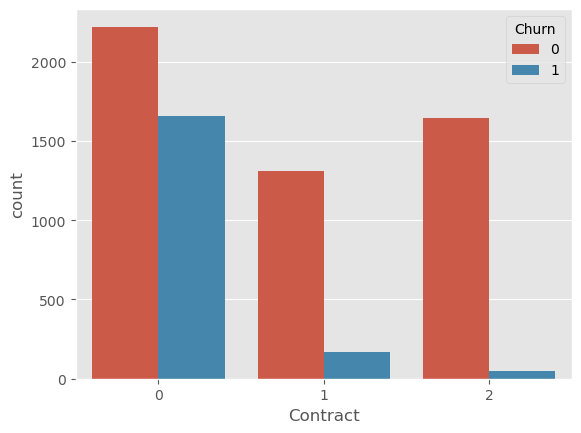

In [59]:
sns.countplot(x="Contract", hue="Churn", data=df)

## EDA SUMMARY
The exploratory data analysis indicates that customer churn is influenced by several demographic and service-related factors. Customers with month-to-month contracts, fiber optic internet service, higher monthly charges, and shorter tenure are more likely to churn. Gender appears to have little impact on churn, while the dataset shows a class imbalance, with more customers staying than leaving. Overall, tenure, contract type, monthly charges, and internet service emerge as some of the most informative features for predicting customer churn using Logistic Regression.

## DATA PREPROCESSING

In [27]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [29]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [32]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
# Drop customerID
df.drop('customerID', axis=1, inplace=True)

In [34]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Encode target variable
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [36]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [37]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [60]:
# One-Hot Encode all categorical features
df = pd.get_dummies(df, drop_first=True)

In [61]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X[num_cols] = scaler.fit_transform(X[num_cols])

In [65]:
# Features
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [70]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5634, 19)
Testing Features: (1409, 19)
Training Target: (5634,)
Testing Target: (1409,)


## DATA PREPROCESSING SUMMARY
During data preprocessing, the customerID column was removed as it does not contribute to predicting customer churn. The TotalCharges column was converted from object to numeric format, and missing values created during conversion were replaced with the median value. The target variable, Churn, was encoded into binary values (No = 0, Yes = 1), while the remaining categorical features were transformed using One-Hot Encoding to create binary variables suitable for Logistic Regression. The dataset was then divided into feature (X) and target (y) variables, followed by an 80:20 stratified train-test split to preserve the original class distribution. Finally, the numerical features (tenure, MonthlyCharges, and TotalCharges) were standardized using StandardScaler, ensuring they were on a comparable scale for efficient model training.

## MODEL BUILDING

In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [73]:
# Train the Logistic Regression model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [74]:
# Predict customer churn on the test dataset
y_pred = model.predict(X_test)

In [75]:
comparison = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Predicted Churn': y_pred
})

comparison.head(10)

,Actual Churn,Predicted Churn
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,1,0


In [76]:
LogisticRegression(
    solver="liblinear",
    C=1,
    max_iter=1000,
    random_state=42
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [77]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
15,PaperlessBilling,0.389271
7,InternetService,0.236618
1,SeniorCitizen,0.165784
6,MultipleLines,0.087923
16,PaymentMethod,0.082850
2,Partner,0.038587
17,MonthlyCharges,0.023954
0,gender,0.011398
12,StreamingTV,0.003251
13,StreamingMovies,0.001045


## MODEL BUILDING SUMMARY
A Logistic Regression model was successfully trained using the processed Telco Customer Churn dataset. The model learned the relationship between customer demographics, subscribed services, billing information, and churn status. Predictions were generated for the test dataset, and the learned coefficients provide insight into the factors influencing churn. Features such as Paperless Billing, Internet Service, and Senior Citizen increase the likelihood of churn, whereas Contract Type, Phone Service, Online Security, and Tech Support reduce the probability of churn. These learned relationships will be validated further using classification metrics in the model evaluation stage.

## MODEL EVALUATION

In [78]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8408974657056498

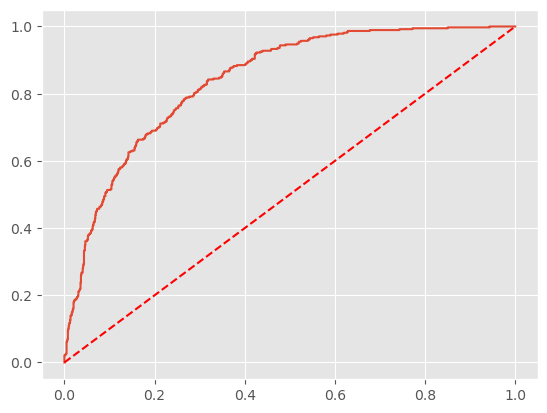

In [79]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'r--')

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [81]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")

Accuracy Score : 0.7984
Precision      : 0.6398
Recall         : 0.5508
F1-Score       : 0.5920


In [82]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[919 116]
 [168 206]]


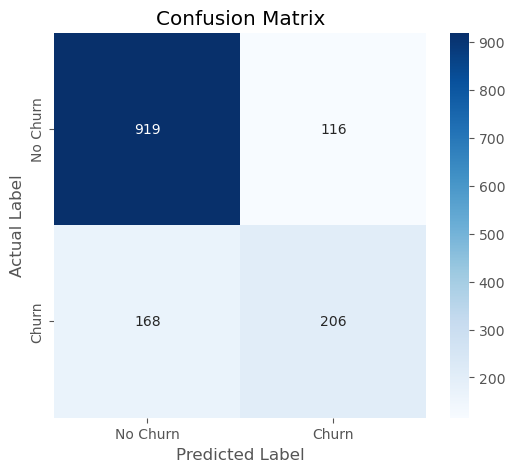

In [83]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [84]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Observation 1

The Logistic Regression model achieved an Accuracy Score of 79.84%, indicating that it correctly classified the majority of customer records. The ROC-AUC Score of 0.8409 suggests that the model has a good ability to distinguish between customers who are likely to churn and those who are not.

## Observation 2

The confusion matrix shows that the model correctly predicted 919 non-churning customers and 206 churning customers. However, it incorrectly classified 168 customers who actually churned as non-churners (false negatives) and 116 customers as churners when they were not (false positives).

## Observation 3

The model achieved a Precision of 63.98%, Recall of 55.08%, and an F1-Score of 59.20%. While the model performs reasonably well overall, the relatively lower recall indicates that some customers who are likely to churn are not being identified. Improving recall through techniques such as feature engineering, hyperparameter tuning, or handling class imbalance could further enhance the model's effectiveness.

## MODEL EVALUATION SUMMARY
The Logistic Regression model demonstrated satisfactory performance in predicting customer churn, achieving an Accuracy Score of 79.84% and a ROC-AUC Score of 0.8409. The confusion matrix and evaluation metrics indicate that the model effectively identifies most non-churning customers while also detecting a substantial number of customers at risk of churn. Although the model provides a strong baseline for churn prediction, improving recall would help identify more potential churners and support more effective customer retention strategies.